# 09c — Pharmacophore-Constrained Molecular Generation / Candidate Acquisition

## PEARL Pipeline 5

This notebook consumes the **09b screening-ready pharmacophore** and creates the first
small-molecule / peptidomimetic candidate set for Pipeline 5.

The finalized 09b model contains:

```text
5 MANDATORY pharmacophore groups
4 OPTIONAL pharmacophore groups
1 CONTEXT group

Screening rule:
ALL 5 mandatory groups
+
at least 1 optional group
```

### Two execution backends

09c deliberately separates the **scientific selection logic** from the **molecule source**.

```text
A. rdkit_prototype
   - runs locally with RDKit;
   - creates a reproducible technical candidate library by BRICS-style recombination;
   - intended to validate the full pharmacophore-matching workflow.

B. reinvent4_external
   - uses an externally installed REINVENT4 executable / generated SMILES file;
   - intended for final generative production once REINVENT4 is configured.
```

The default is `rdkit_prototype` so the notebook can be executed immediately.

**Important:** the prototype generator is not presented as a substitute for the final
REINVENT4 generative experiment. Its purpose is to validate candidate generation/acquisition,
3D conformer generation, pharmacophore matching, ranking, export and QC before the more
expensive production stage.


## 1. Scientific strategy

09b provides an MD-derived, consolidated receptor-recognition pattern. 09c asks whether
chemically valid small molecules can realize the same **relative 3D arrangement** of
pharmacophore features.

The matching procedure is invariant to global translation and rotation:

1. generate or acquire valid SMILES;
2. create 3D conformers;
3. detect RDKit chemical features;
4. match candidate feature points to all mandatory 09b groups;
5. align matched candidate points to the 09b pharmacophore by Kabsch superposition;
6. count optional groups that can also be satisfied;
7. rank candidates by:
   - complete mandatory match;
   - optional matches;
   - pharmacophore RMSD;
   - normalized tolerance score.

No docking or binding-energy claim is made in 09c. Those are downstream validation layers.


In [1]:
from pathlib import Path
import json
import itertools
import shutil
import subprocess
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDConfig
from rdkit.Chem import (
    AllChem,
    BRICS,
    ChemicalFeatures,
    Descriptors,
    Lipinski,
    Crippen,
    rdMolDescriptors,
)

print("RDKit environment loaded.")


RDKit environment loaded.


## 2. Configuration


In [2]:
# ======================================================
# Execution mode
# ======================================================

GENERATION_BACKEND = "rdkit_prototype"
# Other supported value:
# GENERATION_BACKEND = "reinvent4_external"
GENERATION_BACKEND = "reinvent4_external"
FAST_TEST_MODE = False

RANDOM_SEED = 20260817

if FAST_TEST_MODE:
    MODE_LABEL = "smoke_test"
    TARGET_LIBRARY_SIZE = 120
    N_CONFORMERS_PER_MOL = 3
    MAX_MATCH_ASSIGNMENTS = 2000
else:
    MODE_LABEL = "production"
    TARGET_LIBRARY_SIZE = 1000
    N_CONFORMERS_PER_MOL = 10
    MAX_MATCH_ASSIGNMENTS = 10000

# ======================================================
# Pharmacophore matching
# ======================================================

MAX_MANDATORY_RMSD_A = 2.50

# Relative pairwise-distance mismatch allowed while
# constructing candidate feature assignments.
PAIR_DISTANCE_SLACK_A = 2.50

# Optional group accepted after mandatory alignment if the
# aligned candidate feature falls within:
OPTIONAL_TOLERANCE_SCALE = 1.25

# ======================================================
# Input: finalized 09b
# ======================================================

OUTPUTS_ROOT = Path("outputs")

INPUT_ROOT_09B = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09b_consolidated"
)

MODEL_09B_JSON = (
    INPUT_ROOT_09B
    / "models"
    / "09b_screening_ready_pharmacophore.json"
)

MODEL_09B_CSV = (
    INPUT_ROOT_09B
    / "tables"
    / "09b_screening_ready_pharmacophore.csv"
)

QC_09B_PATH = (
    INPUT_ROOT_09B
    / "tables"
    / "09b_QC.csv"
)

# ======================================================
# Optional REINVENT4 integration
# ======================================================

REINVENT4_EXECUTABLE = shutil.which("reinvent")

# If using an externally completed REINVENT4 run,
# put a CSV/SMI file here. The loader accepts a column named
# SMILES/smiles or a one-SMILES-per-line .smi/.txt file.
REINVENT4_GENERATED_SMILES = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09c_generation"
    / "reinvent4"
    / "generated_smiles.csv"
)

# ======================================================
# Output
# ======================================================

OUTPUT_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09c_generation"
    / MODE_LABEL
)

TABLE_DIR = OUTPUT_ROOT / "tables"
MODEL_DIR = OUTPUT_ROOT / "models"
STRUCTURE_DIR = OUTPUT_ROOT / "structures"
PLOT_DIR = OUTPUT_ROOT / "plots"
REPORT_DIR = OUTPUT_ROOT / "reports"
REINVENT_DIR = OUTPUT_ROOT / "reinvent4"

for d in [
    TABLE_DIR,
    MODEL_DIR,
    STRUCTURE_DIR,
    PLOT_DIR,
    REPORT_DIR,
    REINVENT_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)

print("Mode:", MODE_LABEL)
print("Backend:", GENERATION_BACKEND)
print("Target library size:", TARGET_LIBRARY_SIZE)
print("REINVENT4 executable:", REINVENT4_EXECUTABLE)


Mode: production
Backend: reinvent4_external
Target library size: 1000
REINVENT4 executable: None


## 3. Load and validate the 09b pharmacophore


In [3]:
required_paths = [
    MODEL_09B_JSON,
    MODEL_09B_CSV,
    QC_09B_PATH,
]

missing = [
    p
    for p in required_paths
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing 09b outputs:\n"
        + "\n".join(
            str(p)
            for p in missing
        )
    )

with MODEL_09B_JSON.open(
    "r",
    encoding="utf-8",
) as handle:
    pharma_json = json.load(
        handle
    )

pharma_df = pd.read_csv(
    MODEL_09B_CSV
)

qc09b = pd.read_csv(
    QC_09B_PATH
)

qc_values = (
    qc09b["pass"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "false": False,
    })
)

if qc_values.isna().any():
    qc_values = qc09b[
        "pass"
    ].astype(
        bool
    )

if not bool(
    qc_values.all()
):
    raise RuntimeError(
        "09b QC is not fully passed."
    )

mandatory_df = pharma_df[
    pharma_df["role"]
    == "MANDATORY"
].copy()

optional_df = pharma_df[
    pharma_df["role"]
    == "OPTIONAL"
].copy()

print(
    "Mandatory groups:",
    len(mandatory_df),
)

print(
    "Optional groups:",
    len(optional_df),
)

display(
    pharma_df[
        [
            "group_id",
            "role",
            "chemistry_mode",
            "feature_families",
            "x_A",
            "y_A",
            "z_A",
            "tolerance_A",
        ]
    ]
)

if len(
    mandatory_df
) != 5:
    raise RuntimeError(
        "The finalized 09b model is expected to contain 5 mandatory groups."
    )

if len(
    optional_df
) != 4:
    raise RuntimeError(
        "The finalized 09b model is expected to contain 4 optional groups."
    )


Mandatory groups: 5
Optional groups: 4


,group_id,role,chemistry_mode,feature_families,x_A,y_A,z_A,tolerance_A
0,PG01,MANDATORY,"ANY_OF(HBD,POS)","HBD,POS",49.794657,30.436239,45.565561,1.598238
1,PG02,MANDATORY,HYD,HYD,49.179592,41.926508,55.570514,1.729471
2,PG03,MANDATORY,"ANY_OF(ARO,HYD)","ARO,HYD",53.910534,36.722378,54.232110,2.015119
3,PG04,MANDATORY,"ANY_OF(HBA,HBD)","HBA,HBD",56.047425,35.913194,52.677189,2.225775
4,PG05,MANDATORY,HBD,HBD,52.346881,36.474574,50.085317,1.500000
5,PG07,OPTIONAL,HYD,HYD,52.069077,36.610771,62.514597,1.500000
6,PG08,OPTIONAL,"ANY_OF(HBD,POS)","HBD,POS",52.004954,47.789542,63.628426,1.500000
7,PG09,OPTIONAL,"ANY_OF(HBA,NEG)","HBA,NEG",50.256623,39.361287,43.817816,1.596598
8,PG10,OPTIONAL,"ANY_OF(HBD,POS)","HBD,POS",45.323375,33.203490,60.033630,1.574702


## 4. Prepare RDKit pharmacophore feature factory

RDKit feature families are mapped to the PEARL 09b families:

```text
Donor          -> HBD
Acceptor       -> HBA
Hydrophobe     -> HYD
LumpedHydrophobe -> HYD
Aromatic       -> ARO
PosIonizable   -> POS
NegIonizable   -> NEG
```

Composite 09b groups such as `ANY_OF(HBD,POS)` accept either family.


In [4]:
fdef_path = (
    Path(
        RDConfig.RDDataDir
    )
    / "BaseFeatures.fdef"
)

FEATURE_FACTORY = (
    ChemicalFeatures
    .BuildFeatureFactory(
        str(
            fdef_path
        )
    )
)

RDKIT_TO_PEARL = {
    "Donor": "HBD",
    "Acceptor": "HBA",
    "Hydrophobe": "HYD",
    "LumpedHydrophobe": "HYD",
    "Aromatic": "ARO",
    "PosIonizable": "POS",
    "NegIonizable": "NEG",
}

def parse_feature_families(
    value
):
    return {
        x.strip()
        for x in str(
            value
        ).split(",")
        if x.strip()
    }

print(
    "Feature definition:",
    fdef_path
)


Feature definition: /Users/robertobruzzese/miniforge3/envs/pearl-md/share/RDKit/Data/BaseFeatures.fdef


## 5. Molecule source — RDKit prototype library

The prototype generator uses a reproducible set of generic medicinal-chemistry seed
structures and BRICS decomposition/recombination.

This stage is intentionally labelled a **technical prototype generator**. It is used to test
the complete PEARL pharmacophore workflow locally.

The final generative experiment can later replace this source with REINVENT4 without
changing the downstream 09c matching code.


In [5]:
PROTOTYPE_SEED_SMILES = [
    "c1ccccc1C(=O)NCCN",
    "c1ncccc1C(=O)NCCO",
    "c1ccncc1NC(=O)CCN",
    "c1ccc(cc1)OCCN",
    "c1ccc(cc1)CNC(=O)N",
    "c1nccnc1NCCO",
    "c1ccc2ncccc2c1C(=O)N",
    "c1ccc(cc1)S(=O)(=O)NCCN",
    "c1ccccc1NCC(=O)O",
    "c1ncccc1OCCN",
    "c1ccc(cc1)NC(=O)CO",
    "c1ccncc1CNC(=O)O",
    "NCCOc1ccc(cc1)C(=O)N",
    "O=C(NCCN)c1ccc(nc1)N",
    "c1ccc(cc1)C(=O)NCC2CCOCC2",
    "c1ncccc1C(=O)NCC2CCNCC2",
    "c1ccc(cc1)OCC2CCNCC2",
    "c1ccncc1NC(=O)NCC2CCOCC2",
]

def canonical_smiles(
    smiles
):
    mol = Chem.MolFromSmiles(
        smiles
    )

    if mol is None:
        return None

    return Chem.MolToSmiles(
        mol,
        canonical=True,
    )

prototype_seed_mols = [
    Chem.MolFromSmiles(
        smi
    )
    for smi in PROTOTYPE_SEED_SMILES
]

prototype_seed_mols = [
    mol
    for mol in prototype_seed_mols
    if mol is not None
]

fragments = set()

for mol in prototype_seed_mols:
    for frag in BRICS.BRICSDecompose(
        mol
    ):
        fragments.add(
            frag
        )

fragment_mols = [
    Chem.MolFromSmiles(
        frag
    )
    for frag in fragments
]

fragment_mols = [
    mol
    for mol in fragment_mols
    if mol is not None
]

print(
    "Prototype seeds:",
    len(
        prototype_seed_mols
    )
)

print(
    "Unique BRICS fragments:",
    len(
        fragment_mols
    )
)


Prototype seeds: 18
Unique BRICS fragments: 22


In [6]:
def basic_candidate_accept(
    mol
):
    if mol is None:
        return False

    if len(
        Chem.GetMolFrags(
            mol
        )
    ) != 1:
        return False

    heavy = mol.GetNumHeavyAtoms()

    if heavy < 12 or heavy > 45:
        return False

    mw = Descriptors.MolWt(
        mol
    )

    if mw < 150 or mw > 650:
        return False

    return True


def build_rdkit_prototype_library(
    target_size,
):
    smiles_set = set()

    # Retain original generic seeds.
    for mol in prototype_seed_mols:
        if basic_candidate_accept(
            mol
        ):
            smiles_set.add(
                Chem.MolToSmiles(
                    mol,
                    canonical=True,
                )
            )

    # BRICSBuild is deterministic for a fixed fragment list,
    # while the final subset is shuffled with RANDOM_SEED.
    builder = BRICS.BRICSBuild(
        fragment_mols,
        maxDepth=3,
        scrambleReagents=False,
    )

    hard_cap = max(
        target_size * 20,
        1000,
    )

    for i, mol in enumerate(
        builder
    ):
        if i >= hard_cap:
            break

        try:
            Chem.SanitizeMol(
                mol
            )
        except Exception:
            continue

        if not basic_candidate_accept(
            mol
        ):
            continue

        smiles_set.add(
            Chem.MolToSmiles(
                mol,
                canonical=True,
            )
        )

        if len(
            smiles_set
        ) >= target_size * 3:
            break

    smiles_list = sorted(
        smiles_set
    )

    rng = random.Random(
        RANDOM_SEED
    )

    rng.shuffle(
        smiles_list
    )

    return smiles_list[
        :target_size
    ]


## 6. Optional external REINVENT4 candidate loader

REINVENT4 is not required for the local smoke test.

When a final REINVENT4 run has produced a SMILES file, switch:

```python
GENERATION_BACKEND = "reinvent4_external"
```

and point `REINVENT4_GENERATED_SMILES` to the generated file.

The notebook then uses the exact same 3D pharmacophore matching and ranking pipeline.


In [7]:
def load_external_smiles(
    path
):
    path = Path(
        path
    )

    if not path.exists():
        raise FileNotFoundError(
            f"External generated SMILES file not found: {path}"
        )

    if path.suffix.lower() in {
        ".csv",
        ".tsv",
    }:
        sep = (
            "\t"
            if path.suffix.lower()
            == ".tsv"
            else ","
        )

        df = pd.read_csv(
            path,
            sep=sep,
        )

        smiles_col = next(
            (
                c
                for c in [
                    "SMILES",
                    "smiles",
                    "Smiles",
                ]
                if c in df.columns
            ),
            None,
        )

        if smiles_col is None:
            raise RuntimeError(
                "No SMILES column found in external file."
            )

        raw = df[
            smiles_col
        ].dropna(
        ).astype(
            str
        ).tolist()

    else:
        raw = [
            line.strip().split()[0]
            for line in path.read_text(
                encoding="utf-8"
            ).splitlines()
            if line.strip()
        ]

    cleaned = []

    seen = set()

    for smi in raw:
        can = canonical_smiles(
            smi
        )

        if can is None:
            continue

        if can in seen:
            continue

        seen.add(
            can
        )

        cleaned.append(
            can
        )

    return cleaned


## 7. Acquire the candidate SMILES library


In [8]:
if GENERATION_BACKEND == "rdkit_prototype":
    candidate_smiles = (
        build_rdkit_prototype_library(
            TARGET_LIBRARY_SIZE
        )
    )

elif GENERATION_BACKEND == "reinvent4_external":
    candidate_smiles = (
        load_external_smiles(
            REINVENT4_GENERATED_SMILES
        )
    )

    if len(
        candidate_smiles
    ) > TARGET_LIBRARY_SIZE:
        candidate_smiles = candidate_smiles[
            :TARGET_LIBRARY_SIZE
        ]

else:
    raise ValueError(
        "Unsupported GENERATION_BACKEND: "
        + str(
            GENERATION_BACKEND
        )
    )

candidate_input_df = pd.DataFrame({
    "candidate_id": [
        f"MOL{i:05d}"
        for i in range(
            1,
            len(
                candidate_smiles
            )
            + 1,
        )
    ],
    "smiles": candidate_smiles,
    "generation_backend": GENERATION_BACKEND,
})

display(
    candidate_input_df.head(
        20
    )
)

print(
    "Unique candidate SMILES acquired:",
    len(
        candidate_input_df
    ),
)

candidate_input_df.to_csv(
    TABLE_DIR
    / "09c_generated_or_acquired_smiles.csv",
    index=False,
)

if len(
    candidate_input_df
) == 0:
    raise RuntimeError(
        "No candidate molecules were acquired."
    )


,candidate_id,smiles,generation_backend
0,MOL00001,Cc1c(C(=O)O)ccc(-c2cccc(Cl)c2)c1-c1ccc(-c2cccc...,reinvent4_external
1,MOL00002,O=C(Cc1n[nH]c2ccccc12)N1CCCC1CO,reinvent4_external
2,MOL00003,CCCOC1CC(C(C)CC)CCC1NCC,reinvent4_external
3,MOL00004,O=C(NCc1ccc(Oc2ccccc2)cc1)C(c1ccccc1)n1cnc2ccc...,reinvent4_external
4,MOL00005,C=CCC12C=CC=CC1CC(=O)C2,reinvent4_external
5,MOL00006,Cc1ccc(CNC(=O)C(C)Oc2ccc(C#N)cc2Cl)cc1,reinvent4_external
6,MOL00007,COC(=O)C=Cc1ccc(OCCCCCCOS(=O)(=O)c2ccc(C)cc2)cc1,reinvent4_external
7,MOL00008,C=C(C=CC=CC)C(=CC)c1ccnc(C=CC=CC)n1,reinvent4_external
8,MOL00009,Cc1cc(C(N)Cc2cc(Br)cc(Br)c2)sc1Cl,reinvent4_external
9,MOL00010,COc1ccc(C=C2SC(=NS(=O)(=O)c3ccccc3)N(c3ccc(C)c...,reinvent4_external


Unique candidate SMILES acquired: 1000


## 8. Generate 3D conformers

09c performs only minimal validity checks here. Full drug-likeness, PAINS/reactivity and
synthetic-property filtering are intentionally deferred to **09d**.

For each valid molecule:

- explicit H atoms are added;
- ETKDG conformers are embedded;
- MMFF94 (or UFF fallback) is used for light geometry optimization.


In [9]:
def embed_candidate(
    smiles,
    n_conformers,
    seed,
):
    mol = Chem.MolFromSmiles(
        smiles
    )

    if mol is None:
        return None, []

    mol = Chem.AddHs(
        mol
    )

    params = AllChem.ETKDGv3()

    params.randomSeed = int(
        seed
    )

    params.pruneRmsThresh = 0.5

    conf_ids = list(
        AllChem.EmbedMultipleConfs(
            mol,
            numConfs=int(
                n_conformers
            ),
            params=params,
        )
    )

    if not conf_ids:
        return mol, []

    for conf_id in conf_ids:
        try:
            if AllChem.MMFFHasAllMoleculeParams(
                mol
            ):
                AllChem.MMFFOptimizeMolecule(
                    mol,
                    confId=int(conf_id),
                    maxIters=200,
                )
    
            elif AllChem.UFFHasAllMoleculeParams(
                mol
            ):
                AllChem.UFFOptimizeMolecule(
                    mol,
                    confId=int(conf_id),
                    maxIters=200,
                )
    
            else:
                # Keep the ETKDG conformer but skip force-field
                # optimization when neither MMFF nor UFF has a
                # complete parameter set.
                pass
    
        except Exception:
            pass

    return mol, conf_ids


embedded = {}

embed_rows = []

for idx, row in candidate_input_df.iterrows():
    mol, conf_ids = embed_candidate(
        row["smiles"],
        N_CONFORMERS_PER_MOL,
        RANDOM_SEED
        + int(
            idx
        ),
    )

    embedded[
        row["candidate_id"]
    ] = (
        mol,
        conf_ids,
    )

    embed_rows.append({
        "candidate_id": row["candidate_id"],
        "smiles": row["smiles"],
        "embed_success": (
            mol is not None
            and len(
                conf_ids
            )
            > 0
        ),
        "n_conformers": len(
            conf_ids
        ),
    })

embed_df = pd.DataFrame(
    embed_rows
)

display(
    embed_df.head(
        20
    )
)

print(
    "3D embedding success:",
    int(
        embed_df[
            "embed_success"
        ].sum()
    ),
    "/",
    len(
        embed_df
    ),
)

embed_df.to_csv(
    TABLE_DIR
    / "09c_3D_embedding_QC.csv",
    index=False,
)


[13:59:31] UFFTYPER: Unrecognized charge state for atom: 1
[13:59:58] UFFTYPER: Unrecognized charge state for atom: 1
[14:00:26] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[14:00:26] UFFTYPER: Unrecognized charge state for atom: 4
[14:03:25] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:03:26] UFFTYPER: Unrecognized atom type: S_5+6 (38)
[14:06:01] UFFTYPER: Unrecognized atom type: S_5+4 (21)
[14:06:14] UFFTYPER: Unrecognized charge state for atom: 5
[14:06:42] UFFTYPER: Unrec

,candidate_id,smiles,embed_success,n_conformers
0,MOL00001,Cc1c(C(=O)O)ccc(-c2cccc(Cl)c2)c1-c1ccc(-c2cccc...,True,5
1,MOL00002,O=C(Cc1n[nH]c2ccccc12)N1CCCC1CO,True,9
2,MOL00003,CCCOC1CC(C(C)CC)CCC1NCC,True,10
3,MOL00004,O=C(NCc1ccc(Oc2ccccc2)cc1)C(c1ccccc1)n1cnc2ccc...,True,10
4,MOL00005,C=CCC12C=CC=CC1CC(=O)C2,True,7
5,MOL00006,Cc1ccc(CNC(=O)C(C)Oc2ccc(C#N)cc2Cl)cc1,True,9
6,MOL00007,COC(=O)C=Cc1ccc(OCCCCCCOS(=O)(=O)c2ccc(C)cc2)cc1,True,10
7,MOL00008,C=C(C=CC=CC)C(=CC)c1ccnc(C=CC=CC)n1,True,10
8,MOL00009,Cc1cc(C(N)Cc2cc(Br)cc(Br)c2)sc1Cl,True,9
9,MOL00010,COc1ccc(C=C2SC(=NS(=O)(=O)c3ccccc3)N(c3ccc(C)c...,True,8


3D embedding success: 996 / 1000


## 9. Extract candidate pharmacophore feature points


In [23]:
def rdkit_feature_points(
    mol,
    conf_id,
):
    conf = mol.GetConformer(
        int(
            conf_id
        )
    )

    output = []

    for feat in FEATURE_FACTORY.GetFeaturesForMol(
        mol
    ):
        family = RDKIT_TO_PEARL.get(
            feat.GetFamily()
        )

        if family is None:
            continue

        atom_ids = list(
            feat.GetAtomIds()
        )

        if not atom_ids:
            continue

        xyz = np.array([
            [
                conf.GetAtomPosition(
                    int(
                        atom_id
                    )
                ).x,
                conf.GetAtomPosition(
                    int(
                        atom_id
                    )
                ).y,
                conf.GetAtomPosition(
                    int(
                        atom_id
                    )
                ).z,
            ]
            for atom_id in atom_ids
        ], dtype=float)

        center = xyz.mean(
            axis=0
        )

        output.append({
            "family": family,
            "x": float(
                center[0]
            ),
            "y": float(
                center[1]
            ),
            "z": float(
                center[2]
            ),
            "atom_ids": tuple(
                int(
                    x
                )
                for x in atom_ids
            ),
        })

    return output


## 10. Pharmacophore matching helpers

The mandatory match is solved by a constrained feature-assignment search.

The search uses only **relative pairwise distances** during assignment, so it is independent
of the arbitrary initial orientation of the RDKit conformer.

Once a complete assignment is found, a Kabsch transformation aligns the candidate
pharmacophore points onto the 09b reference coordinates and yields a 3D RMSD.


In [24]:
MANDATORY_GROUPS = (
    mandatory_df
    .reset_index(
        drop=True
    )
)

OPTIONAL_GROUPS = (
    optional_df
    .reset_index(
        drop=True
    )
)

TARGET_MANDATORY_XYZ = (
    MANDATORY_GROUPS[
        [
            "x_A",
            "y_A",
            "z_A",
        ]
    ]
    .to_numpy(
        dtype=float
    )
)

TARGET_MANDATORY_DIST = np.linalg.norm(
    TARGET_MANDATORY_XYZ[
        :,
        None,
        :
    ]
    - TARGET_MANDATORY_XYZ[
        None,
        :,
        :
    ],
    axis=2,
)

def kabsch_fit(
    mobile_xyz,
    target_xyz,
):
    mobile_xyz = np.asarray(
        mobile_xyz,
        dtype=float,
    )

    target_xyz = np.asarray(
        target_xyz,
        dtype=float,
    )

    mobile_center = mobile_xyz.mean(
        axis=0
    )

    target_center = target_xyz.mean(
        axis=0
    )

    x = (
        mobile_xyz
        - mobile_center
    )

    y = (
        target_xyz
        - target_center
    )

    covariance = (
        x.T
        @ y
    )

    u, s, vt = np.linalg.svd(
        covariance
    )

    rotation = (
        u
        @ vt
    )

    if np.linalg.det(
        rotation
    ) < 0:
        vt[
            -1,
            :
        ] *= -1

        rotation = (
            u
            @ vt
        )

    aligned = (
        x
        @ rotation
        + target_center
    )

    rmsd = float(
        np.sqrt(
            np.mean(
                np.sum(
                    (
                        aligned
                        - target_xyz
                    )
                    ** 2,
                    axis=1,
                )
            )
        )
    )

    translation = (
        target_center
        - mobile_center
        @ rotation
    )

    return (
        rmsd,
        rotation,
        translation,
        aligned,
    )


def transformed_point(
    point,
    rotation,
    translation,
):
    point = np.asarray(
        point,
        dtype=float,
    )

    return (
        point
        @ rotation
        + translation
    )


In [25]:
def allowed_indices_for_group(
    features,
    group_row,
):
    allowed_families = (
        parse_feature_families(
            group_row[
                "feature_families"
            ]
        )
    )

    return [
        i
        for i, feature in enumerate(
            features
        )
        if feature[
            "family"
        ]
        in allowed_families
    ]


def best_mandatory_assignment(
    features,
):
    allowed = [
        allowed_indices_for_group(
            features,
            MANDATORY_GROUPS.iloc[
                i
            ],
        )
        for i in range(
            len(
                MANDATORY_GROUPS
            )
        )
    ]

    if any(
        len(
            choices
        )
        == 0
        for choices in allowed
    ):
        return None

    # Search the most constrained pharmacophore groups first.
    order = sorted(
        range(
            len(
                allowed
            )
        ),
        key=lambda i: len(
            allowed[i]
        ),
    )

    best = None
    visited = 0

    assignment = {}

    used_feature_ids = set()

    def recurse(
        depth
    ):
        nonlocal best
        nonlocal visited

        if visited >= MAX_MATCH_ASSIGNMENTS:
            return

        if depth == len(
            order
        ):
            visited += 1

            candidate_xyz = np.array([
                [
                    features[
                        assignment[i]
                    ]["x"],
                    features[
                        assignment[i]
                    ]["y"],
                    features[
                        assignment[i]
                    ]["z"],
                ]
                for i in range(
                    len(
                        MANDATORY_GROUPS
                    )
                )
            ], dtype=float)

            (
                rmsd,
                rotation,
                translation,
                aligned,
            ) = kabsch_fit(
                candidate_xyz,
                TARGET_MANDATORY_XYZ,
            )

            if (
                best is None
                or rmsd < best[
                    "rmsd_A"
                ]
            ):
                best = {
                    "rmsd_A": rmsd,
                    "assignment": dict(
                        assignment
                    ),
                    "rotation": rotation,
                    "translation": translation,
                    "aligned_xyz": aligned,
                    "visited": visited,
                }

            return

        group_i = order[
            depth
        ]

        for feature_i in allowed[
            group_i
        ]:
            if feature_i in used_feature_ids:
                continue

            feature_xyz = np.array([
                features[
                    feature_i
                ]["x"],
                features[
                    feature_i
                ]["y"],
                features[
                    feature_i
                ]["z"],
            ])

            compatible = True

            for other_group_i, other_feature_i in assignment.items():
                other_xyz = np.array([
                    features[
                        other_feature_i
                    ]["x"],
                    features[
                        other_feature_i
                    ]["y"],
                    features[
                        other_feature_i
                    ]["z"],
                ])

                observed_d = float(
                    np.linalg.norm(
                        feature_xyz
                        - other_xyz
                    )
                )

                target_d = float(
                    TARGET_MANDATORY_DIST[
                        group_i,
                        other_group_i,
                    ]
                )

                tolerance = (
                    PAIR_DISTANCE_SLACK_A
                    + float(
                        MANDATORY_GROUPS.iloc[
                            group_i
                        ]["tolerance_A"]
                    )
                    + float(
                        MANDATORY_GROUPS.iloc[
                            other_group_i
                        ]["tolerance_A"]
                    )
                ) / 2.0

                if abs(
                    observed_d
                    - target_d
                ) > tolerance:
                    compatible = False
                    break

            if not compatible:
                continue

            assignment[
                group_i
            ] = feature_i

            used_feature_ids.add(
                feature_i
            )

            recurse(
                depth + 1
            )

            used_feature_ids.remove(
                feature_i
            )

            del assignment[
                group_i
            ]

    recurse(
        0
    )

    if best is not None:
        best[
            "visited"
        ] = visited

    return best


## 11. Evaluate optional groups after mandatory superposition


In [26]:
def evaluate_optional_groups(
    features,
    mandatory_result,
):
    rotation = mandatory_result[
        "rotation"
    ]

    translation = mandatory_result[
        "translation"
    ]

    used = set(
        mandatory_result[
            "assignment"
        ].values()
    )

    optional_hits = []

    for _, group in OPTIONAL_GROUPS.iterrows():
        allowed_families = parse_feature_families(
            group[
                "feature_families"
            ]
        )

        target = np.array([
            group[
                "x_A"
            ],
            group[
                "y_A"
            ],
            group[
                "z_A"
            ],
        ], dtype=float)

        threshold = float(
            group[
                "tolerance_A"
            ]
        ) * OPTIONAL_TOLERANCE_SCALE

        best = None

        for feature_i, feature in enumerate(
            features
        ):
            if feature_i in used:
                continue

            if feature[
                "family"
            ] not in allowed_families:
                continue

            original = np.array([
                feature["x"],
                feature["y"],
                feature["z"],
            ])

            aligned = transformed_point(
                original,
                rotation,
                translation,
            )

            distance = float(
                np.linalg.norm(
                    aligned
                    - target
                )
            )

            if (
                best is None
                or distance
                < best[
                    "distance_A"
                ]
            ):
                best = {
                    "group_id": group[
                        "group_id"
                    ],
                    "feature_index": feature_i,
                    "feature_family": feature[
                        "family"
                    ],
                    "distance_A": distance,
                    "threshold_A": threshold,
                    "matched": (
                        distance
                        <= threshold
                    ),
                }

        if best is not None:
            optional_hits.append(
                best
            )

    return optional_hits


## 12. Run 3D pharmacophore matching

A molecule passes the 09c pharmacophore screen when:

```text
mandatory assignment exists
mandatory RMSD <= MAX_MANDATORY_RMSD_A
at least 1 OPTIONAL group is matched
```

The notebook evaluates every embedded conformer and retains the best conformer per molecule.


In [27]:
match_rows = []

best_match_objects = {}

for row_index, row in candidate_input_df.iterrows():
    candidate_id = row[
        "candidate_id"
    ]

    mol, conf_ids = embedded[
        candidate_id
    ]

    best_candidate = None

    if (
        mol is None
        or not conf_ids
    ):
        match_rows.append({
            "candidate_id": candidate_id,
            "smiles": row["smiles"],
            "mandatory_match": False,
            "mandatory_rmsd_A": np.nan,
            "n_optional_matched": 0,
            "screen_pass": False,
        })
        continue

    for conf_id in conf_ids:
        features = rdkit_feature_points(
            mol,
            conf_id,
        )

        mandatory_result = (
            best_mandatory_assignment(
                features
            )
        )

        if mandatory_result is None:
            continue

        optional_hits = (
            evaluate_optional_groups(
                features,
                mandatory_result,
            )
        )

        n_optional = sum(
            int(
                hit[
                    "matched"
                ]
            )
            for hit in optional_hits
        )

        rmsd_A = float(
            mandatory_result[
                "rmsd_A"
            ]
        )

        screen_pass = (
            rmsd_A
            <= MAX_MANDATORY_RMSD_A
            and n_optional
            >= int(
                pharma_json[
                    "screening_rule"
                ][
                    "min_optional_matches"
                ]
            )
        )

        # Higher optional matches first; then lower RMSD.
        rank_key = (
            -n_optional,
            rmsd_A,
        )

        candidate_result = {
            "candidate_id": candidate_id,
            "smiles": row["smiles"],
            "conf_id": int(
                conf_id
            ),
            "mandatory_match": True,
            "mandatory_rmsd_A": rmsd_A,
            "n_optional_matched": int(
                n_optional
            ),
            "optional_match_ids": ",".join(
                hit[
                    "group_id"
                ]
                for hit in optional_hits
                if hit[
                    "matched"
                ]
            ),
            "screen_pass": bool(
                screen_pass
            ),
            "rank_key": rank_key,
            "features": features,
            "mandatory_result": mandatory_result,
            "optional_hits": optional_hits,
        }

        if (
            best_candidate is None
            or rank_key
            < best_candidate[
                "rank_key"
            ]
        ):
            best_candidate = candidate_result

    if best_candidate is None:
        match_rows.append({
            "candidate_id": candidate_id,
            "smiles": row["smiles"],
            "mandatory_match": False,
            "mandatory_rmsd_A": np.nan,
            "n_optional_matched": 0,
            "optional_match_ids": "",
            "screen_pass": False,
        })

    else:
        match_rows.append({
            key: value
            for key, value in best_candidate.items()
            if key
            in {
                "candidate_id",
                "smiles",
                "conf_id",
                "mandatory_match",
                "mandatory_rmsd_A",
                "n_optional_matched",
                "optional_match_ids",
                "screen_pass",
            }
        })

        best_match_objects[
            candidate_id
        ] = best_candidate

match_df = pd.DataFrame(
    match_rows
)

display(
    match_df.sort_values(
        [
            "screen_pass",
            "n_optional_matched",
            "mandatory_rmsd_A",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    ).head(
        30
    )
)

print(
    "Mandatory geometries found:",
    int(
        match_df[
            "mandatory_match"
        ].sum()
    ),
)

print(
    "Screening passes:",
    int(
        match_df[
            "screen_pass"
        ].sum()
    ),
)

match_df.to_csv(
    TABLE_DIR
    / "09c_pharmacophore_match_all_candidates.csv",
    index=False,
)


,candidate_id,smiles,mandatory_match,mandatory_rmsd_A,n_optional_matched,optional_match_ids,screen_pass,conf_id
569,MOL00570,CCCC=CCCCCCCCC(=O)OCC(CO)OC(=O)COC1OC(CO)C(O)C...,True,1.561656,1,PG09,True,6.0
335,MOL00336,COc1cnccc1-c1ccc2[nH]c(CC3=CCC4(C(COCC=O)C(=O)...,True,1.778733,1,PG07,True,4.0
512,MOL00513,COc1cc(C=NNC(=O)c2cc(NC(=O)c3ccc4c(c3)NC(c3ccc...,True,0.832790,0,,False,8.0
685,MOL00686,C=CC(=O)NC1Cc2cc(Nc3nc(-c4cncc(C(=N)S(C)(C)C)c...,True,0.888151,0,,False,5.0
341,MOL00342,CCCCCCC(S)CN(CCCS)CCCC[N+](C)(CCCSC)CCc1ccc(CC...,True,0.889731,0,,False,8.0
201,MOL00202,CCCCc1ccc(N=C(NN=Cc2cc(SCC(O)COc3ccc4ccccc4c3)...,True,0.932058,0,,False,3.0
718,MOL00719,CCC=CCC=CCC=CCC=CCC=CCCCC(=O)NCCOCCOCCC(=O)NCC...,True,0.946764,0,,False,5.0
756,MOL00757,NC(=O)CCCCCCCCNc1nc2c(O)cccc2cc1C(=O)c1cc(Cl)c...,True,0.951182,0,,False,6.0
127,MOL00128,NC(=O)c1c(NC(=O)c2cc3c(-c4ncccc4Cl)ccc(F)c3[nH...,True,0.992449,0,,False,3.0
13,MOL00014,CC1C=c2c(C3=CC4CCCC4c4ncccc4N3)nc(NC3CCN(C(=O)...,True,0.992882,0,,False,7.0


Mandatory geometries found: 83
Screening passes: 2


## 13. Add descriptive molecular properties


In [28]:
property_rows = []

for row in candidate_input_df.itertuples():
    mol = Chem.MolFromSmiles(
        row.smiles
    )

    if mol is None:
        continue

    property_rows.append({
        "candidate_id": row.candidate_id,
        "MW": float(
            Descriptors.MolWt(
                mol
            )
        ),
        "cLogP": float(
            Crippen.MolLogP(
                mol
            )
        ),
        "HBD": int(
            Lipinski.NumHDonors(
                mol
            )
        ),
        "HBA": int(
            Lipinski.NumHAcceptors(
                mol
            )
        ),
        "TPSA": float(
            rdMolDescriptors.CalcTPSA(
                mol
            )
        ),
        "RotB": int(
            Lipinski.NumRotatableBonds(
                mol
            )
        ),
        "rings": int(
            rdMolDescriptors.CalcNumRings(
                mol
            )
        ),
    })

property_df = pd.DataFrame(
    property_rows
)

rank_df = match_df.merge(
    property_df,
    on="candidate_id",
    how="left",
)

# Descriptive pharmacophore score only.
# It is NOT a binding score.
rank_df[
    "pharmacophore_score"
] = (
    rank_df[
        "n_optional_matched"
    ].fillna(
        0
    )
    + np.exp(
        -rank_df[
            "mandatory_rmsd_A"
        ].fillna(
            99
        )
    )
)

rank_df = rank_df.sort_values(
    [
        "screen_pass",
        "n_optional_matched",
        "mandatory_rmsd_A",
    ],
    ascending=[
        False,
        False,
        True,
    ],
).reset_index(
    drop=True
)

rank_df.insert(
    0,
    "09c_rank",
    np.arange(
        1,
        len(
            rank_df
        )
        + 1,
    ),
)

display(
    rank_df.head(
        30
    )
)

rank_df.to_csv(
    TABLE_DIR
    / "09c_candidate_ranking.csv",
    index=False,
)


,09c_rank,candidate_id,smiles,mandatory_match,mandatory_rmsd_A,n_optional_matched,optional_match_ids,screen_pass,conf_id,MW,cLogP,HBD,HBA,TPSA,RotB,rings,pharmacophore_score
0,1,MOL00570,CCCC=CCCCCCCCC(=O)OCC(CO)OC(=O)COC1OC(CO)C(O)C...,True,1.561656,1,PG09,True,6.0,668.730,-1.83860,8,16,251.36,21,2,1.209788
1,2,MOL00336,COc1cnccc1-c1ccc2[nH]c(CC3=CCC4(C(COCC=O)C(=O)...,True,1.778733,1,PG07,True,4.0,958.298,11.38130,4,8,164.76,10,12,1.168852
2,3,MOL00513,COc1cc(C=NNC(=O)c2cc(NC(=O)c3ccc4c(c3)NC(c3ccc...,True,0.832790,0,,False,8.0,822.746,6.22610,6,10,189.51,12,7,0.434834
3,4,MOL00686,C=CC(=O)NC1Cc2cc(Nc3nc(-c4cncc(C(=N)S(C)(C)C)c...,True,0.888151,0,,False,5.0,476.610,3.04817,4,8,142.56,6,4,0.411416
4,5,MOL00342,CCCCCCC(S)CN(CCCS)CCCC[N+](C)(CCCSC)CCc1ccc(CC...,True,0.889731,0,,False,8.0,602.122,8.35220,3,5,3.24,26,1,0.410766
5,6,MOL00202,CCCCc1ccc(N=C(NN=Cc2cc(SCC(O)COc3ccc4ccccc4c3)...,True,0.932058,0,,False,3.0,617.793,6.84900,4,8,123.74,14,4,0.393743
6,7,MOL00719,CCC=CCC=CCC=CCC=CCC=CCCCC(=O)NCCOCCOCCC(=O)NCC...,True,0.946764,0,,False,5.0,594.837,6.81510,2,5,85.89,26,1,0.387994
7,8,MOL00757,NC(=O)CCCCCCCCNc1nc2c(O)cccc2cc1C(=O)c1cc(Cl)c...,True,0.951182,0,,False,6.0,469.969,5.15830,4,6,125.54,12,3,0.386284
8,9,MOL00128,NC(=O)c1c(NC(=O)c2cc3c(-c4ncccc4Cl)ccc(F)c3[nH...,True,0.992449,0,,False,3.0,495.946,3.66590,3,5,121.93,7,5,0.370668
9,10,MOL00014,CC1C=c2c(C3=CC4CCCC4c4ncccc4N3)nc(NC3CCN(C(=O)...,True,0.992882,0,,False,7.0,526.689,2.72800,4,7,107.10,5,7,0.370507


## 14. Select the 09c pharmacophore-positive set

Only pharmacophore-positive candidates are exported as the main 09c output.

If the prototype generator produces few or zero hits, that is scientifically informative:
the next action is to expand/tune the candidate-generation stage, **not** to weaken the 09b
pharmacophore automatically.


In [29]:
positive_df = rank_df[
    rank_df[
        "screen_pass"
    ]
].copy()

positive_df.to_csv(
    TABLE_DIR
    / "09c_pharmacophore_positive_candidates.csv",
    index=False,
)

print(
    "Pharmacophore-positive candidates:",
    len(
        positive_df
    ),
)

display(
    positive_df.head(
        25
    )
)


Pharmacophore-positive candidates: 2


,09c_rank,candidate_id,smiles,mandatory_match,mandatory_rmsd_A,n_optional_matched,optional_match_ids,screen_pass,conf_id,MW,cLogP,HBD,HBA,TPSA,RotB,rings,pharmacophore_score
0,1,MOL00570,CCCC=CCCCCCCCC(=O)OCC(CO)OC(=O)COC1OC(CO)C(O)C...,True,1.561656,1,PG09,True,6.0,668.730,-1.8386,8,16,251.36,21,2,1.209788
1,2,MOL00336,COc1cnccc1-c1ccc2[nH]c(CC3=CCC4(C(COCC=O)C(=O)...,True,1.778733,1,PG07,True,4.0,958.298,11.3813,4,8,164.76,10,12,1.168852


## 15. Export best aligned candidate structures


In [30]:
TOP_STRUCTURE_EXPORTS = min(
    20,
    len(
        positive_df
    ),
)

sdf_path = (
    STRUCTURE_DIR
    / "09c_top_pharmacophore_aligned_candidates.sdf"
)

writer = Chem.SDWriter(
    str(
        sdf_path
    )
)

exported = 0

for row in positive_df.head(
    TOP_STRUCTURE_EXPORTS
).itertuples():
    best = best_match_objects.get(
        row.candidate_id
    )

    if best is None:
        continue

    mol, conf_ids = embedded[
        row.candidate_id
    ]

    conf_id = int(
        best[
            "conf_id"
        ]
    )

    export_mol = Chem.Mol(
        mol
    )

    conf = export_mol.GetConformer(
        conf_id
    )

    rotation = best[
        "mandatory_result"
    ][
        "rotation"
    ]

    translation = best[
        "mandatory_result"
    ][
        "translation"
    ]

    for atom_i in range(
        export_mol.GetNumAtoms()
    ):
        p = conf.GetAtomPosition(
            atom_i
        )

        transformed = transformed_point(
            np.array([
                p.x,
                p.y,
                p.z,
            ]),
            rotation,
            translation,
        )

        conf.SetAtomPosition(
            atom_i,
            (
                float(
                    transformed[0]
                ),
                float(
                    transformed[1]
                ),
                float(
                    transformed[2]
                ),
            ),
        )

    export_mol.SetProp(
        "_Name",
        row.candidate_id,
    )

    export_mol.SetProp(
        "SMILES",
        row.smiles,
    )

    export_mol.SetProp(
        "mandatory_rmsd_A",
        f"{row.mandatory_rmsd_A:.4f}",
    )

    export_mol.SetProp(
        "n_optional_matched",
        str(
            int(
                row.n_optional_matched
            )
        ),
    )

    writer.write(
        export_mol,
        confId=conf_id,
    )

    exported += 1

writer.close()

print(
    "Aligned SDF structures exported:",
    exported,
)

print(
    "SDF:",
    sdf_path,
)


Aligned SDF structures exported: 2
SDF: outputs/pipeline_5_pharmacophore_09c_generation/production/structures/09c_top_pharmacophore_aligned_candidates.sdf


## 16. Diagnostic plots


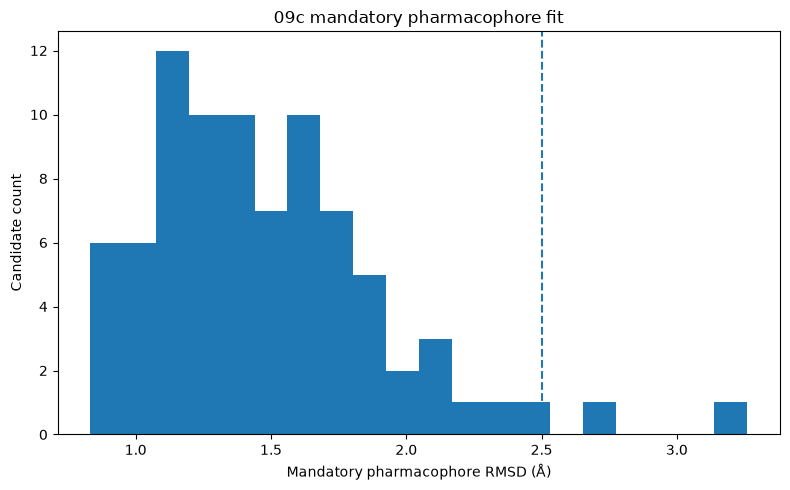

Saved: outputs/pipeline_5_pharmacophore_09c_generation/production/plots/09c_mandatory_rmsd_distribution.png


In [31]:
plot_df = match_df[
    match_df[
        "mandatory_rmsd_A"
    ].notna()
].copy()

if len(
    plot_df
):
    plt.figure(
        figsize=(8, 5)
    )

    plt.hist(
        plot_df[
            "mandatory_rmsd_A"
        ],
        bins=20,
    )

    plt.axvline(
        MAX_MANDATORY_RMSD_A,
        linestyle="--",
    )

    plt.xlabel(
        "Mandatory pharmacophore RMSD (Å)"
    )

    plt.ylabel(
        "Candidate count"
    )

    plt.title(
        "09c mandatory pharmacophore fit"
    )

    plt.tight_layout()

    path = (
        PLOT_DIR
        / "09c_mandatory_rmsd_distribution.png"
    )

    plt.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        path,
    )


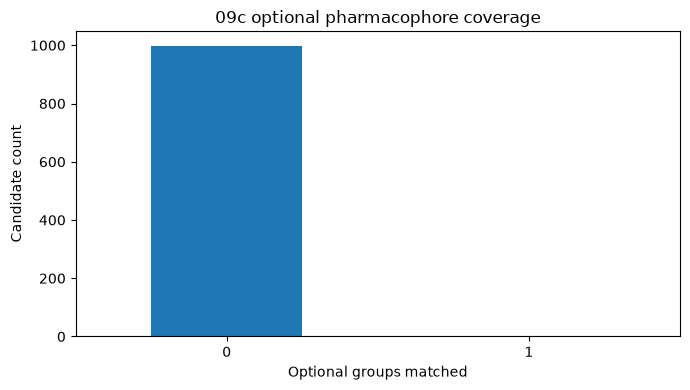

Saved: outputs/pipeline_5_pharmacophore_09c_generation/production/plots/09c_optional_match_counts.png


In [32]:
if len(
    rank_df
):
    counts = (
        rank_df[
            "n_optional_matched"
        ]
        .value_counts()
        .sort_index()
    )

    ax = counts.plot(
        kind="bar",
        figsize=(7, 4),
    )

    ax.set_xlabel(
        "Optional groups matched"
    )

    ax.set_ylabel(
        "Candidate count"
    )

    ax.set_title(
        "09c optional pharmacophore coverage"
    )

    plt.xticks(
        rotation=0
    )

    plt.tight_layout()

    path = (
        PLOT_DIR
        / "09c_optional_match_counts.png"
    )

    plt.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        path,
    )


## 17. Prepare a REINVENT4 handoff manifest

The exact REINVENT4 run configuration is intentionally kept external to the pharmacophore
matcher because REINVENT4 versions and model/prior paths are installation-specific.

09c therefore exports a machine-readable handoff manifest containing:

- the finalized 09b pharmacophore path;
- generation target size;
- the required downstream screening rule;
- output location expected by `reinvent4_external`.

This keeps the PEARL analysis reproducible without hard-coding a locally invalid prior/model
path.


In [33]:
reinvent_manifest = {
    "purpose": (
        "PEARL Pipeline 5 pharmacophore-guided molecular generation"
    ),
    "recommended_tool": "REINVENT4",
    "reinvent_executable_detected": (
        REINVENT4_EXECUTABLE
        is not None
    ),
    "target_generated_molecules": int(
        TARGET_LIBRARY_SIZE
    ),
    "pharmacophore_model_json": str(
        MODEL_09B_JSON
    ),
    "pharmacophore_model_csv": str(
        MODEL_09B_CSV
    ),
    "required_screening_rule": pharma_json[
        "screening_rule"
    ],
    "expected_generated_smiles_path": str(
        REINVENT4_GENERATED_SMILES
    ),
    "note": (
        "REINVENT4 should generate chemically valid, diverse small molecules. "
        "The PEARL-specific 3D pharmacophore constraint is evaluated by this "
        "09c notebook after generation, preserving a tool-independent scoring layer."
    ),
}

manifest_path = (
    REINVENT_DIR
    / "09c_REINVENT4_handoff_manifest.json"
)

manifest_path.write_text(
    json.dumps(
        reinvent_manifest,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    json.dumps(
        reinvent_manifest,
        indent=2,
    )
)


{
  "purpose": "PEARL Pipeline 5 pharmacophore-guided molecular generation",
  "recommended_tool": "REINVENT4",
  "reinvent_executable_detected": false,
  "target_generated_molecules": 1000,
  "pharmacophore_model_json": "outputs/pipeline_5_pharmacophore_09b_consolidated/models/09b_screening_ready_pharmacophore.json",
  "pharmacophore_model_csv": "outputs/pipeline_5_pharmacophore_09b_consolidated/tables/09b_screening_ready_pharmacophore.csv",
  "required_screening_rule": {
    "mandatory_match_rule": "ALL",
    "optional_match_rule": "AT_LEAST_N",
    "min_optional_matches": 1,
    "composite_group_rule": "ANY listed feature family may satisfy the group",
    "distance_rule": "candidate feature center must lie within group tolerance_A"
  },
  "expected_generated_smiles_path": "outputs/pipeline_5_pharmacophore_09c_generation/reinvent4/generated_smiles.csv",
  "note": "REINVENT4 should generate chemically valid, diverse small molecules. The PEARL-specific 3D pharmacophore constraint is e

## 18. Quality control

The prototype smoke test is considered technically successful even if no molecule passes
the final pharmacophore, provided candidate acquisition, 3D embedding and matching all run.

`positive_candidates_nonempty` is reported separately because a zero-hit result should trigger
generator expansion or REINVENT4 production, not silent pharmacophore relaxation.


In [34]:
n_inputs = len(
    candidate_input_df
)

n_embedded = int(
    embed_df[
        "embed_success"
    ].sum()
)

n_mandatory_geometry = int(
    match_df[
        "mandatory_match"
    ].sum()
)

n_positive = int(
    match_df[
        "screen_pass"
    ].sum()
)

qc_rows = [
    {
        "check": "09b_QC_passed",
        "pass": bool(
            qc_values.all()
        ),
    },
    {
        "check": "five_mandatory_groups_loaded",
        "pass": (
            len(
                mandatory_df
            )
            == 5
        ),
    },
    {
        "check": "four_optional_groups_loaded",
        "pass": (
            len(
                optional_df
            )
            == 4
        ),
    },
    {
        "check": "candidate_library_nonempty",
        "pass": (
            n_inputs
            > 0
        ),
    },
    {
        "check": "3D_embedding_success_rate_ge_50pct",
        "pass": (
            n_embedded
            >= max(
                1,
                int(
                    0.50
                    * n_inputs
                ),
            )
        ),
    },
    {
        "check": "pharmacophore_matching_executed",
        "pass": (
            len(
                match_df
            )
            == n_inputs
        ),
    },
    {
        "check": "ranking_exported",
        "pass": (
            TABLE_DIR
            / "09c_candidate_ranking.csv"
        ).exists(),
    },
    {
        "check": "reinvent_handoff_manifest_created",
        "pass": (
            manifest_path.exists()
        ),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

ALL_TECHNICAL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(
    qc_df
)

print(
    "ALL TECHNICAL QC PASSED:",
    ALL_TECHNICAL_QC_PASSED,
)

print(
    "PHARMACOPHORE POSITIVE CANDIDATES:",
    n_positive,
)

qc_df.to_csv(
    TABLE_DIR
    / "09c_QC.csv",
    index=False,
)


,check,pass
0,09b_QC_passed,True
1,five_mandatory_groups_loaded,True
2,four_optional_groups_loaded,True
3,candidate_library_nonempty,True
4,3D_embedding_success_rate_ge_50pct,True
5,pharmacophore_matching_executed,True
6,ranking_exported,True
7,reinvent_handoff_manifest_created,True


ALL TECHNICAL QC PASSED: True
PHARMACOPHORE POSITIVE CANDIDATES: 2


## 19. Automatic report


In [35]:
report_lines = [
    "# 09c — Pharmacophore-Constrained Molecular Generation / Candidate Acquisition",
    "",
    f"- Mode: {MODE_LABEL}",
    f"- Generation backend: {GENERATION_BACKEND}",
    f"- Candidate SMILES acquired: {n_inputs}",
    f"- Molecules successfully embedded in 3D: {n_embedded}",
    f"- Molecules with complete mandatory feature assignment: {n_mandatory_geometry}",
    f"- Pharmacophore-positive candidates: {n_positive}",
    "",
    "## Pharmacophore rule",
    f"- Mandatory groups: {len(mandatory_df)} / all required",
    (
        f"- Optional groups: {len(optional_df)} / at least "
        f"{pharma_json['screening_rule']['min_optional_matches']} required"
    ),
    f"- Maximum mandatory RMSD: {MAX_MANDATORY_RMSD_A:.2f} Å",
    "",
    "## Top candidates",
]

for row in rank_df.head(
    20
).itertuples():
    report_lines.append(
        (
            f"- {row.candidate_id} | pass={row.screen_pass} | "
            f"optional={int(row.n_optional_matched)} | "
            f"RMSD={row.mandatory_rmsd_A:.3f} Å"
            if pd.notna(
                row.mandatory_rmsd_A
            )
            else (
                f"- {row.candidate_id} | pass={row.screen_pass} | "
                "no complete mandatory assignment"
            )
        )
    )

report_lines.extend([
    "",
    "## Interpretation",
    (
        "09c tests whether generated/acquired small molecules can reproduce "
        "the relative 3D pharmacophore geometry consolidated in 09b."
    ),
    (
        "The current pharmacophore score is a geometric/chemical compatibility "
        "criterion, not a docking score, binding energy or biological activity measurement."
    ),
    (
        "The rdkit_prototype backend is a workflow-validation generator. "
        "The final generative experiment should use a larger production source, "
        "preferably REINVENT4 as specified in the PEARL project."
    ),
    (
        "09d should perform chemistry-aware filtering and diversity analysis "
        "on the pharmacophore-positive set before docking."
    ),
    "",
    f"ALL TECHNICAL QC PASSED: {ALL_TECHNICAL_QC_PASSED}",
    f"PHARMACOPHORE POSITIVE CANDIDATES: {n_positive}",
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "09c_generation_and_pharmacophore_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 09c — Pharmacophore-Constrained Molecular Generation / Candidate Acquisition

- Mode: production
- Generation backend: reinvent4_external
- Candidate SMILES acquired: 1000
- Molecules successfully embedded in 3D: 996
- Molecules with complete mandatory feature assignment: 83
- Pharmacophore-positive candidates: 2

## Pharmacophore rule
- Mandatory groups: 5 / all required
- Optional groups: 4 / at least 1 required
- Maximum mandatory RMSD: 2.50 Å

## Top candidates
- MOL00570 | pass=True | optional=1 | RMSD=1.562 Å
- MOL00336 | pass=True | optional=1 | RMSD=1.779 Å
- MOL00513 | pass=False | optional=0 | RMSD=0.833 Å
- MOL00686 | pass=False | optional=0 | RMSD=0.888 Å
- MOL00342 | pass=False | optional=0 | RMSD=0.890 Å
- MOL00202 | pass=False | optional=0 | RMSD=0.932 Å
- MOL00719 | pass=False | optional=0 | RMSD=0.947 Å
- MOL00757 | pass=False | optional=0 | RMSD=0.951 Å
- MOL00128 | pass=False | optional=0 | RMSD=0.992 Å
- MOL00014 | pass=False | optional=0 | RMSD=0.993 Å
- MOL00431

# 20. Final interpretation and next step

There are two legitimate outcomes.

### A. Pharmacophore-positive molecules are obtained

```text
09b screening-ready pharmacophore
        ↓
09c generation/acquisition
        ↓
3D pharmacophore-positive molecules
        ↓
09d chemical filtering + diversity
```

### B. Zero/few prototype hits

Do **not** automatically weaken the 09b pharmacophore.

Instead:

```text
expand generation
        ↓
run REINVENT4 production
        ↓
re-evaluate with the unchanged 09b/09c matcher
```

This preserves the scientific traceability of the MD-derived pharmacophore.

The next formal notebook is:

```text
09d — Chemical filtering, liabilities, drug-likeness and diversity
```

but 09d should be started only after inspecting the 09c hit count and deciding whether the
prototype candidate source is sufficient or REINVENT4 production is needed.
